In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
from coffea import util
from coffea.processor import accumulate
import os
import re
import pandas as pd
import hist
import matplotlib as mpl
import mplhep
import sys
import hist
import hist.intervals

sys.path.append("../analysisTools/")
import plotTools as ptools
import analysisSubroutines as sub
import utils

In [2]:
#coffea output file
# f_sig = "../coffea/corrected_sig_2022/corrected_2022.coffea"
f_sig = "../coffea/corrected_sig_2022/ctau10only_2022.coffea"

#Nested Dictionary:
sig_histo = util.load(f_sig) [0]
print (sig_histo.keys())

dict_keys(['gen_ele_pt', 'gen_ele_eta', 'gen_ele_phi', 'gen_ele_vxy1', 'gen_ele_vxy10', 'gen_ele_vxy100', 'match_ele_gen_pt', 'match_ele_gen_vxy1', 'match_ele_gen_vxy10', 'match_ele_gen_vxy100', 'PFMET', 'PFMET_vs_genMET', 'cutDesc', 'cutflow', 'cutflow_cts', 'cutflow_nevts', 'cutflow_vtx_matched'])


Saved: ./plots//gen_ele_pT.png
Saved: ./plots/signal_2022/match_ele_gen_pt.png


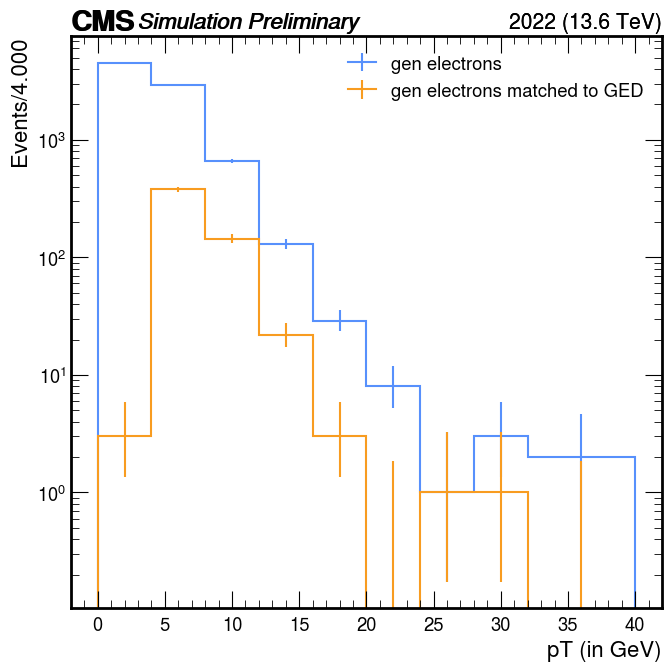

In [3]:
#FOR GED electrons

fig, ax = plt.subplots(figsize=(7,7))

m1=10
delta = 0.1
ctau = 10

# Plot settings
plot_dict = {
    'variable': 'gen_ele_pt',
    'cut': 'cut1',
    'year': 2022
}

style_dict = {
    'fig': fig,
    'ax': ax,
    'rebin': 2j,
    'xlim': None,     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]
    'doLogy': True, 
    'doLogx': False,
    'doDensity': False,
    'doYerr': True, 
    'xlabel': "gen_ele_pt",   # if None, the default will show up; otherwise give as a string, i.e. 'Electron dxy'
    'ylabel': None,   # if None, the default will show up; otherwise give as a string, i.e. 'Efficiency'
    'label': "gen electrons",    # if None, the default will show up; otherwise give as a string, i.e. 'Highest ctau signal samples'
    'flow': None,     # overflow
    'doSave': True,
    'outDir': './plots/',
    'outName': f'gen_ele_pT.png'
}
# #####
count_den, edges_den = ptools.plot_signal_1D_match(sig_histo, m1, delta, ctau, plot_dict, style_dict, match_type='R', passID=1)
count_den = np.array(count_den)

indices = np.where(count_den == 0)
deno = count_den[count_den != 0]  #IMP

#####
den_edges = np.array(edges_den)
bins_deno = np.delete(den_edges, indices)
###########################################################



m1=10
delta = 0.1
ctau = 10
#fig, ax = plt.subplots(figsize=(7,7))

plot_dict = {'variable': 'match_ele_gen_pt', 'cut': 'cut1', 'year': 2022}

style_dict = {
    'fig': fig,
    'ax': ax,
    'rebin': 2j,
    'xlim': None,     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]
    'doLogy': True, 
    'doLogx': False,
    'doDensity': False,
    'doYerr': True, 
    #'xlabel': "pT of gen electrons(matched to 'R')",  
    'xlabel': "pT (in GeV)",              # if None, the default will show up; otherwise give as a string, i.e. 'Electron dxy'
    'ylabel': None,   # if None, the default will show up; otherwise give as a string, i.e. 'Efficiency'
    'label': "gen electrons matched to GED",    # if None, the default will show up; otherwise give as a string, i.e. 'Highest ctau signal samples'
    'flow': None,     # overflow
    'doSave': True,
    'outDir': './plots/signal_2022',
    'outName': f'match_ele_gen_pt.png'
}
count_num, edges_num = ptools.plot_signal_1D_match(sig_histo, m1, delta, ctau, plot_dict, style_dict, match_type='R', passID=1)

#########
count_num = np.array(count_num)
num = np.delete(count_num, indices)
#########

edges_num = np.array(edges_num)
bins_num = np.delete(edges_num, indices)

#Calculation for the efficiency plot
bins_x = (bins_num[:-1] + bins_num[1:])*(0.5)


xerr = (bins_num[1:] - bins_num[:-1])*(0.5)

In [4]:
def eff_determine_unc(n, d):
    eff = np.divide(n, d)
    unc = hist.intervals.ratio_uncertainty(n, d, 'efficiency')
    return eff, unc

efficiency_R, unc_eff_R = eff_determine_unc(num, deno)
print (efficiency_R)
yerr_R = [unc_eff_R[0], unc_eff_R[1]]
print (yerr_R)

[6.62836942e-04 1.29119946e-01 2.16216216e-01 1.69230769e-01
 1.03448276e-01 0.00000000e+00 1.00000000e+00 3.33333333e-01
 0.00000000e+00]
[array([3.60717872e-04, 6.22149385e-03, 1.62472940e-02, 3.38110760e-02,
       5.57628513e-02, 0.00000000e+00, 8.41344746e-01, 2.77375361e-01,
       0.00000000e+00]), array([0.00064434, 0.00648041, 0.01713879, 0.03946681, 0.09049103,
       0.20556786, 0.        , 0.41453471, 0.60168448])]


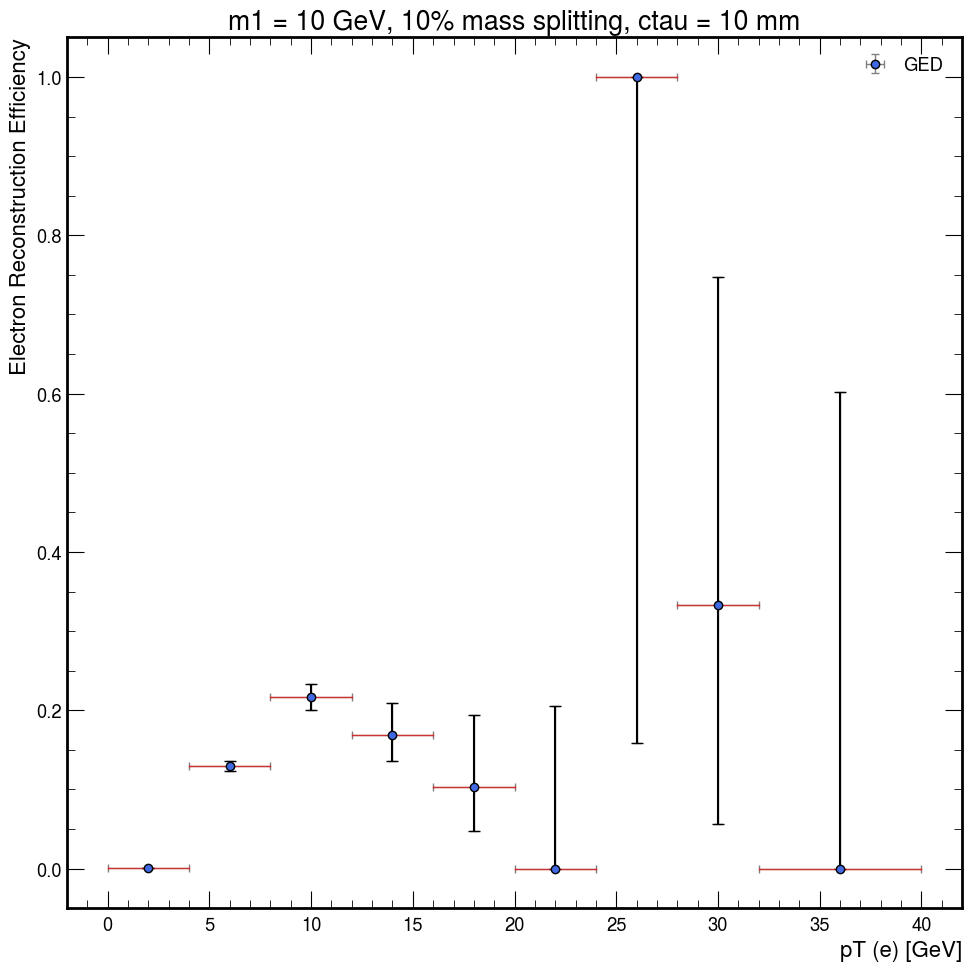

In [5]:
plt.errorbar(
    bins_x, efficiency_R,
    yerr=yerr_R, xerr=xerr,
    fmt='o', markersize=6, markerfacecolor='royalblue', markeredgecolor='black',
    ecolor='gray', elinewidth=1, capsize=3,
    label='GED'
)

# Draw y errors thicker and darker
plt.errorbar(
    bins_x, efficiency_R,
    yerr=yerr_R,
    fmt='none', ecolor='black', elinewidth=1.5, capsize=4
)

# Draw x errors thinner and lighter
plt.errorbar(
    bins_x, efficiency_R,
    xerr=xerr,
    fmt='none', ecolor='red', elinewidth=1, capsize=1, alpha=0.6
)
plt.xlabel("pT (e) [GeV]")
plt.ylabel("Electron Reconstruction Efficiency")
plt.title("m1 = 10 GeV, 10% mass splitting, ctau = 10 mm")
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig("correctedeffplots/gedpT10mm.png", dpi=300)
